In [60]:
import numpy as np
import openml
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from torch import nn
import torch
import torch.nn.functional as F


In [61]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [62]:
CLASS_LABELS = ["walking", "upstairs", "downstairs", "sitting", "standing", "laying"]

dataset = openml.datasets.get_dataset(1478)
X, y, *_ = dataset.get_data(target=dataset.default_target_attribute)
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float32, device=device)
y_test = y_test.astype(int) - 1  # Converts "5" -> 4

X_test.shape, y_test.shape

(torch.Size([2060, 561]), (2060,))

In [63]:
class MLP(nn.Module):
    def __init__(self, n_hidden: int, n_width: int):
        super().__init__()

        self.input_layer = nn.Linear(X.shape[1], n_width)
        self.hidden_layers = nn.ModuleList([nn.Linear(n_width, n_width) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(n_width, len(CLASS_LABELS))
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
        x = self.output_layer(x)
        return x


In [64]:
class Ensemble(nn.Module):
    def __init__(self):
        super().__init__()

        model_params = torch.load("../checkpoints/best/model_params.pth")

        models = []
        for fold in range(5):
            model = MLP(model_params["n_hidden"], model_params["n_width"])
            model.load_state_dict(torch.load(f"../checkpoints/best/fold_{fold}.pth"))
            models.append(model)

        self.models = nn.ModuleList(models)

    def forward(self, x):
        votes, confidences = self.majority_vote(x)
        return votes

    def majority_vote(self, x) -> tuple[torch.Tensor, torch.Tensor]:
        all_outputs = torch.stack([model(x) for model in self.models], dim=0)
        all_preds = torch.argmax(all_outputs, dim=-1)
        majority_votes, _ = torch.mode(all_preds, dim=0)

        num_classes = len(CLASS_LABELS)

        vote_counts = F.one_hot(all_preds, num_classes=num_classes).sum(dim=0).float()

        num_models = len(self.models)

        probs = vote_counts / num_models
        entropy = -torch.sum(probs * torch.log2(probs + 1e-9), dim=1)
        max_entropy = torch.log2(torch.tensor(float(num_models), device=x.device))

        confidence = 1.0 - (entropy / (max_entropy + 1e-9))
        return majority_votes, confidence

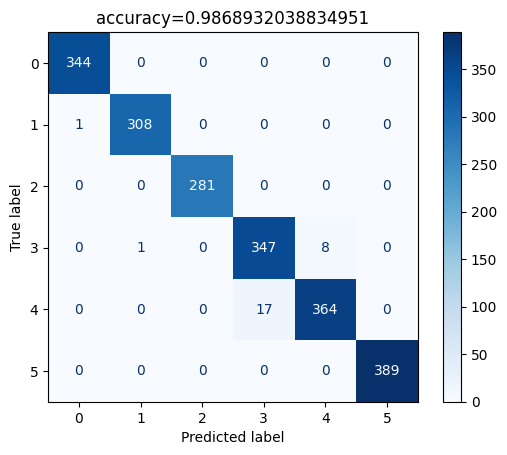

In [67]:
ensemble = Ensemble()
ensemble.eval()

_, ax = plt.subplots(1, 1)

total_loss = 0.0
y_pred = ensemble(X_test)

accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", ax=ax)
ax.set_title(f"{accuracy=}")

plt.show()
